In [2]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [27]:
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2035_NT+fast_3000.nc'
)

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2035_NT+fast_3000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [38]:
n.generators.loc[['BA0 0 0 solar'], ['p_nom', 'p_nom_min', 'p_nom_max', 'p_nom_opt', 'p_nom_extendable']]

,p_nom,p_nom_min,p_nom_max,p_nom_opt,p_nom_extendable
Generator,,,,,
BA0 0 0 solar,883.868019,574.514212,1193.221825,574.517672,True


In [25]:
n.links.columns

Index(['bus0', 'bus1', 'type', 'carrier', 'efficiency', 'active', 'build_year',
       'lifetime', 'p_nom', 'p_nom_mod', 'p_nom_extendable', 'p_nom_min',
       'p_nom_max', 'p_set', 'p_min_pu', 'p_max_pu', 'capital_cost',
       'marginal_cost', 'marginal_cost_quadratic', 'stand_by_cost', 'length',
       'terrain_factor', 'committable', 'start_up_cost', 'shut_down_cost',
       'min_up_time', 'min_down_time', 'up_time_before', 'down_time_before',
       'ramp_limit_up', 'ramp_limit_down', 'ramp_limit_start_up',
       'ramp_limit_shut_down', 'p_nom_opt', 'bus4', 'efficiency4', 'bus3',
       'efficiency3', 'bus2', 'efficiency2', 'location',
       'fixed_profile_scaling_opt', 'under_construction', 'underground',
       'reversed', 'underwater_fraction', 'geometry', 'dc', 'length_original',
       'voltage', 'project_status', 'tags'],
      dtype='object')

In [82]:
path = Path.cwd().parent / 'results' / 'duals'
template = 'base_s_50__168H-T-H-B-I-A-dist1_2035_NT+{}_{}_{}_mu.csv'
fns = list(path.glob('*.csv'))

In [88]:
from tqdm import tqdm

uppers_fast = list()
lowers_fast = list()
uppers_medium = list()
lowers_medium = list()

for wiggle in tqdm(range(1000, 4250, 250)):

    uppers_fast.append(
        pd.read_csv(
            path / template.format('fast', wiggle, 'upper'), index_col=1
        ).iloc[:, 1].rename(wiggle)
    )
    lowers_fast.append(
        pd.read_csv(
            path / template.format('fast', wiggle, 'lower'), index_col=1
        ).iloc[:, 1].rename(wiggle)
    )

    uppers_medium.append(
        pd.read_csv(
            path / template.format('medium', wiggle, 'upper'), index_col=1
        ).iloc[:, 1].rename(wiggle)
    )
    lowers_medium.append(
        pd.read_csv(
            path / template.format('medium', wiggle, 'lower'), index_col=1
        ).iloc[:, 1].rename(wiggle)
    )
    

uppers_fast = pd.concat(uppers_fast, axis=1)
lowers_fast = pd.concat(lowers_fast, axis=1)
uppers_medium = pd.concat(uppers_medium, axis=1)
lowers_medium = pd.concat(lowers_medium, axis=1)

100%|██████████| 13/13 [00:00<00:00, 71.08it/s]


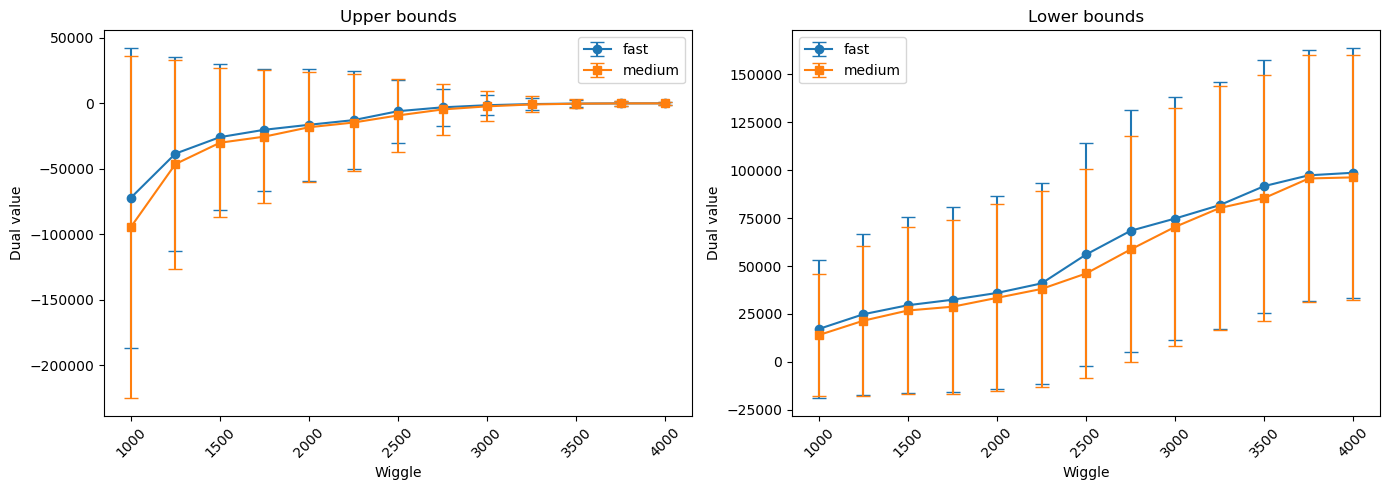

In [94]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

carrier = 'wind'

# Prepare data for upper bounds
ss_fast = uppers_fast.loc[uppers_fast.index.str.contains(carrier)]
ss_medium = uppers_medium.loc[uppers_medium.index.str.contains(carrier)]

# Calculate mean and std for upper bounds
mean_fast_upper = ss_fast.mean()
std_fast_upper = ss_fast.std()
mean_medium_upper = ss_medium.mean()
std_medium_upper = ss_medium.std()

# Plot upper bounds
axs[0].errorbar(mean_fast_upper.index, mean_fast_upper.values, yerr=std_fast_upper.values, 
                label='fast', marker='o', capsize=5)
axs[0].errorbar(mean_medium_upper.index, mean_medium_upper.values, yerr=std_medium_upper.values, 
                label='medium', marker='s', capsize=5)
axs[0].set_title('Upper bounds')
axs[0].set_xlabel('Wiggle')
axs[0].set_ylabel('Dual value')
axs[0].tick_params(axis='x', rotation=45)
axs[0].legend()

# Prepare data for lower bounds
ss_fast_lower = lowers_fast.loc[lowers_fast.index.str.contains(carrier)]
ss_medium_lower = lowers_medium.loc[lowers_medium.index.str.contains(carrier)]

# Calculate mean and std for lower bounds
mean_fast_lower = ss_fast_lower.mean()
std_fast_lower = ss_fast_lower.std()
mean_medium_lower = ss_medium_lower.mean()
std_medium_lower = ss_medium_lower.std()

# Plot lower bounds
axs[1].errorbar(mean_fast_lower.index, mean_fast_lower.values, yerr=std_fast_lower.values, 
                label='fast', marker='o', capsize=5)
axs[1].errorbar(mean_medium_lower.index, mean_medium_lower.values, yerr=std_medium_lower.values, 
                label='medium', marker='s', capsize=5)
axs[1].set_title('Lower bounds')
axs[1].set_xlabel('Wiggle')
axs[1].set_ylabel('Dual value')
axs[1].tick_params(axis='x', rotation=45)
axs[1].legend()

plt.tight_layout()
plt.show()

In [69]:
df = pd.DataFrame({
    'A': [1, 2, 3],
    'B': [4, 5, 6],
    'C': [7, 8, 9]
})
print(df)
y = df.values.flatten()
x = df.columns.tolist() * len(df)

   A  B  C
0  1  4  7
1  2  5  8
2  3  6  9


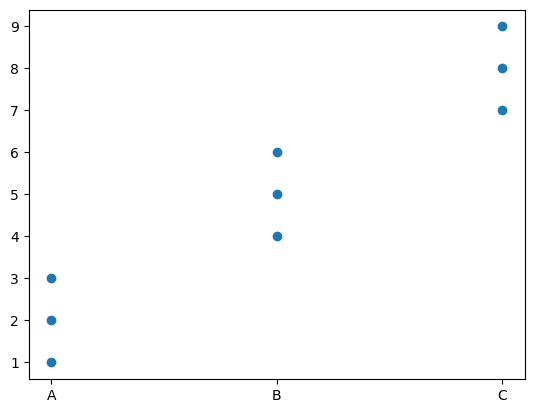

In [70]:
plt.scatter(x, y)